In [1]:
# ==========================================================
# Imports
# ==========================================================

import time
import matplotlib.pyplot as plt

from pyspark import SparkConf, SparkContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, countDistinct

In [2]:
# ==========================================================
# Benchmark function
# ==========================================================

def run_analysis(data, target):

    start = time.time()

    users = (
        data.filter(col("subreddit") == target)
        .select("author")
        .distinct()
    )

    user_posts = data.join(users, "author")

    other_posts = user_posts.filter(col("subreddit") != target)

    result = (
        other_posts.groupBy("subreddit")
        .agg(countDistinct("author").alias("unique_users"))
    )

    result.collect()

    runtime = time.time() - start
    

    return runtime

In [3]:
# ==========================================================
# Horizontal scaling test
# ==========================================================

def run_test(max_cores, num_executors, target_subreddit):
    spark = (
        SparkSession.builder
        .master("spark://group13-master:7077")
        .appName("HorizontalScaling")
        .config("spark.sql.shuffle.partitions", "200")
        .config("spark.cores.max", str(max_cores))
        .config("spark.executor.cores", "2")
        .config("spark.executor.instances", str(num_executors))
        .getOrCreate()
    )
    start = time.time()
    
    # ==========================================================
    # Load dataset
    # ==========================================================
    
    parquet_path = "hdfs:///project/reddit/parquet"
    
    df_parquet = spark.read.parquet(parquet_path)
    
    clean_df = df_parquet.select("author", "subreddit")
    clean_df = clean_df.filter(col("author") != "[deleted]")
    
    print("Rows:", clean_df.count())

    # ==========================================================
    # Run analytics
    # ==========================================================
    
    runtime = run_analysis(clean_df, target_subreddit)

    elapsed = time.time() - start
    print(f"Cores: {max_cores} | Time: {elapsed:.2f}s")

    #SparkContext._gateway = None      
    #SparkContext._jvm = None
    #time.sleep(20)
    
    spark.stop()
    return elapsed

In [4]:
results = {}
target_subreddit = "AskReddit"

for i, cores in enumerate([2, 4, 6]):   # 1 node, 2 nodes, 3 nodes
    results[cores] = run_test(cores, i + 1, target_subreddit)

print("\n=== Horizontal Scaling Results ===")
for cores, t in results.items():
    print(f"  spark.cores.max={cores}, time taken: {t:.2f}s")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/10 10:37:52 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Rows: 2000000


Cores: 2 | Time: 32.49s


Rows: 2000000


Cores: 4 | Time: 19.57s


Rows: 2000000


Cores: 6 | Time: 16.09s

=== Horizontal Scaling Results ===
  spark.cores.max=2, time taken: 32.49s
  spark.cores.max=4, time taken: 19.57s
  spark.cores.max=6, time taken: 16.09s


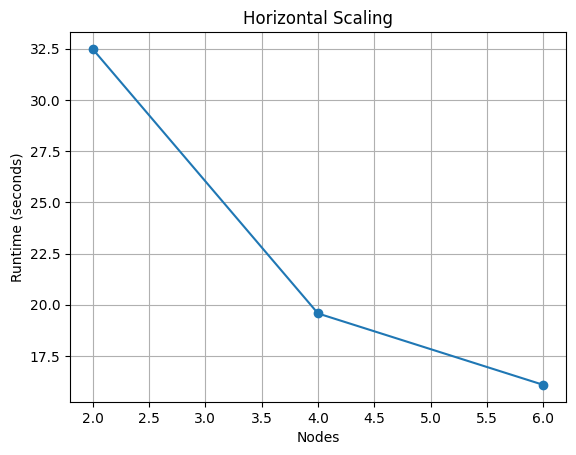

In [9]:
# ==========================================================
# Plot results
# ==========================================================

labels = list(results.keys())
times = list(results.values())

plt.plot(labels, times, marker="o")

plt.xlabel("Nodes")
plt.ylabel("Runtime (seconds)")
plt.title("Horizontal Scaling")
plt.savefig("Horizontal_scaling.svg")

plt.grid(True)
plt.show()